In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline

In [2]:
df = pd.read_csv('Advertising.csv')
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
df = pd.read_csv('Advertising.csv')
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df = df.drop(columns=['Unnamed: 0'])
df.columns = ['TV', 'Radio', 'Newspaper', 'Sales']

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
print("\nDescriptive statistics:\n", df.describe())

Shape: (200, 4)

Data types:
 TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

Missing values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
Duplicate rows: 0

Descriptive statistics:
                TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


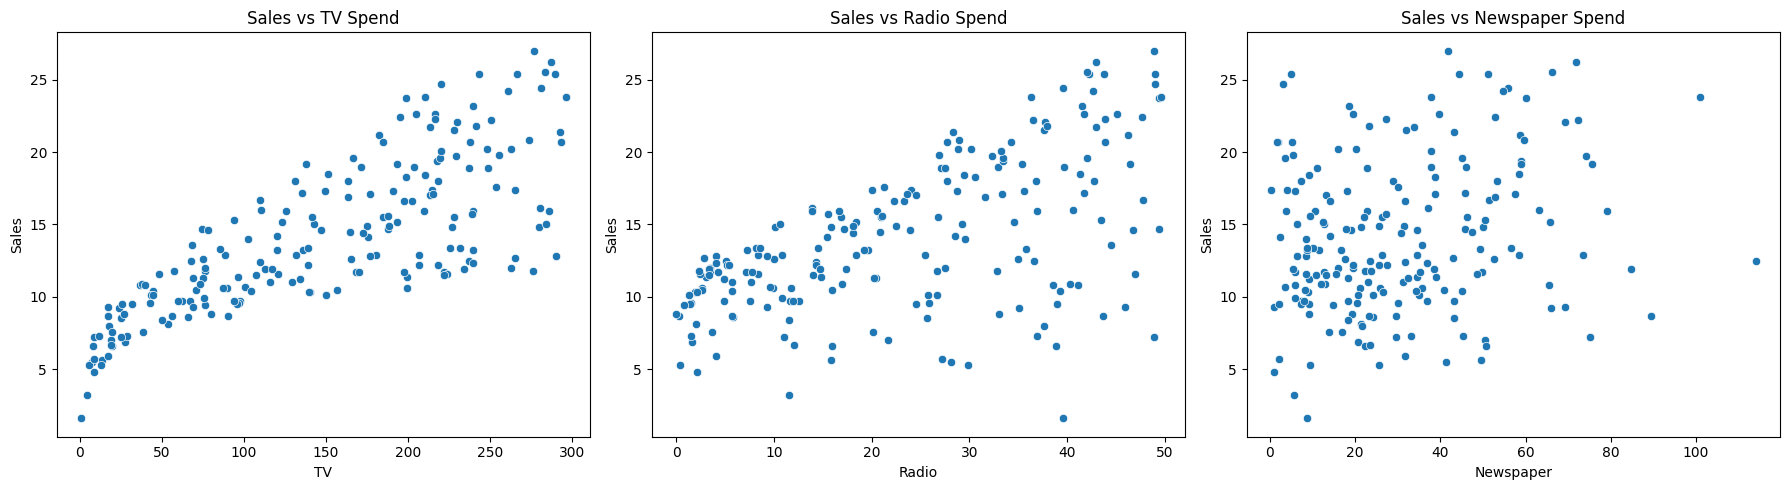

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x='TV', y='Sales', data=df, ax=axes[0])
axes[0].set_title('Sales vs TV Spend')

sns.scatterplot(x='Radio', y='Sales', data=df, ax=axes[1])
axes[1].set_title('Sales vs Radio Spend')

sns.scatterplot(x='Newspaper', y='Sales', data=df, ax=axes[2])
axes[2].set_title('Sales vs Newspaper Spend')

plt.tight_layout()
plt.show()

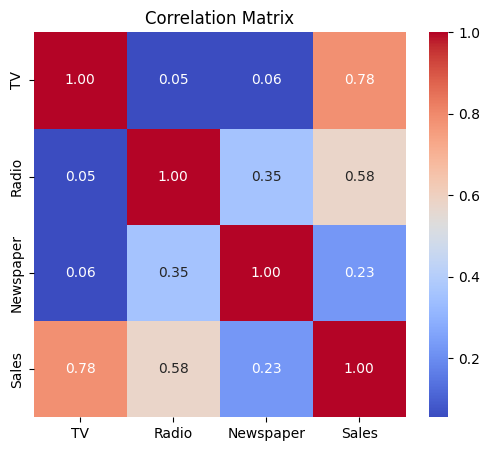

In [6]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [7]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (160, 3)
Testing set size: (40, 3)


In [8]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)
print("Predictions:", y_pred1[:10])
print("Actual:     ", y_test.values[:10])

Predictions: [16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]
Actual:      [16.9 22.4 21.4  7.3 24.7 12.6 22.3  8.4 11.5 14.9]


In [9]:
model2 = RandomForestRegressor(random_state=42)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)
print("Predictions:", y_pred2[:10])
print("Actual:     ", y_test.values[:10])

Predictions: [17.698 21.804 20.619  6.793 22.927 13.379 22.376  9.688 11.826 15.54 ]
Actual:      [16.9 22.4 21.4  7.3 24.7 12.6 22.3  8.4 11.5 14.9]


In [10]:
print("=== Linear Regression ===")
print("MAE:", mean_absolute_error(y_test, y_pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred1)))
print("R² Score:", r2_score(y_test, y_pred1))

print("\n=== Random Forest Regressor ===")
print("MAE:", mean_absolute_error(y_test, y_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred2)))
print("R² Score:", r2_score(y_test, y_pred2))

=== Linear Regression ===
MAE: 1.4607567168117603
RMSE: 1.78159966153345
R² Score: 0.899438024100912

=== Random Forest Regressor ===
MAE: 0.6203249999999988
RMSE: 0.7687170968568338
R² Score: 0.9812782416450916


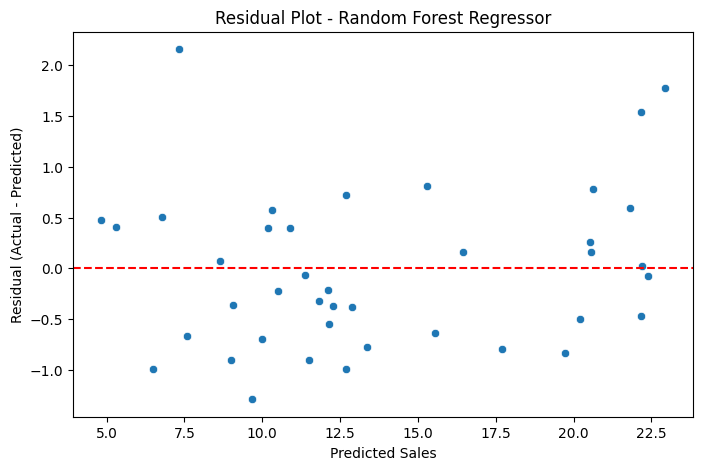

In [11]:
residuals = y_test - y_pred2

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred2, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot - Random Forest Regressor')
plt.show()

In [12]:
# Linear Regression coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model1.coef_
})
print("=== Linear Regression Coefficients ===")
print(coefficients)

# Random Forest feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model2.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\n=== Random Forest Feature Importance ===")
print(importance)

=== Linear Regression Coefficients ===
     Feature  Coefficient
0         TV     0.044730
1      Radio     0.189195
2  Newspaper     0.002761

=== Random Forest Feature Importance ===
     Feature  Importance
0         TV    0.624810
1      Radio    0.362214
2  Newspaper    0.012976


In [ ]:
## Conclusion: Model Selection & Business Insights

Two regression models were trained: Linear Regression and Random Forest Regressor.

**Performance comparison:**
| Metric | Linear Regression | Random Forest |
|---|---|---|
| MAE | 1.46 | 0.62 |
| RMSE | 1.78 | 0.77 |
| R² | 0.899 | 0.981 |

**Chosen model: Random Forest Regressor**

Justification:
- Substantially lower error (MAE, RMSE) and higher R² across the board
- Better able to capture the non-linear, diminishing-returns pattern seen in the
  TV spend scatter plot, which a straight-line model cannot represent
- Residual plot confirmed errors are randomly distributed, with no systematic bias

**Business Interpretation:**
- TV advertising has the strongest overall impact on sales (correlation: 0.78; 
  Random Forest feature importance: 62.5%)
- Radio is the most cost-efficient channel per dollar spent (highest Linear 
  Regression coefficient), but receives a much smaller budget in practice
- Newspaper advertising shows a consistently weak relationship with sales across 
  every method tested (correlation: 0.23; feature importance: 1.3%) and is the 
  safest channel to reduce if budgets are cut